## Data preparation 

In [108]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
# Load both datasets

trader_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

In [110]:
# Preview the data 

print(trader_df.head())
print(sentiment_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [111]:
print("Trader data shape:", trader_df.shape)
print("Sentiment data shape:", sentiment_df.shape)

Trader data shape: (211224, 16)
Sentiment data shape: (2644, 4)


*Trader data :*
number of rows: 211224
number of columns: 16

*Sentiment data :*
number of rows: 2644
number of columns: 4

In [112]:
print("Trader Data Info:")
trader_df.info()

print("\nSentiment Data Info:")
sentiment_df.info()

Trader Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes:

In [113]:
print(trader_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [114]:
print(sentiment_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [115]:
print("\nMissing values (Trader):")
print(trader_df.isna().sum())

print("\nMissing values (Sentiment):")
print(sentiment_df.isna().sum())


Missing values (Trader):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [116]:
trader_df.drop_duplicates(inplace=True)
sentiment_df.drop_duplicates(inplace=True)

*missing values : 0*
*duplicate values : 0*


In [120]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

trades_df= pd.read_csv('historical_data.csv')
sentiment_df= pd.read_csv('fear_greed_index.csv')

trades_df.head()
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [121]:


#converting date columns
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
trades_df['Timestamp'] = pd.to_datetime(trades_df['Timestamp'])

trades_df['date_only'] = trades_df['Timestamp'].dt.date
sentiment_df['Date_only'] = sentiment_df['date'].dt.date

trades_df.dropna(inplace=True)
sentiment_df.dropna(inplace=True)

In [122]:
trades_df['date_only'] = pd.to_datetime(
    trades_df['Timestamp IST'], format="%d-%m-%Y %H:%M", errors='coerce'
).dt.date

sentiment_df['Date_only'] = pd.to_datetime(sentiment_df['date'], errors='coerce').dt.date

# Merge on date
merged_df = pd.merge(
    trades_df,
    sentiment_df[['Date_only', 'classification']],
    left_on='date_only',
    right_on='Date_only',
    how='left'
)

# Clean up column name
merged_df.rename(columns={'Classification': 'classification'}, inplace=True)

# Check merge result
merged_df['classification'].value_counts(dropna=False)


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [123]:
merged_df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

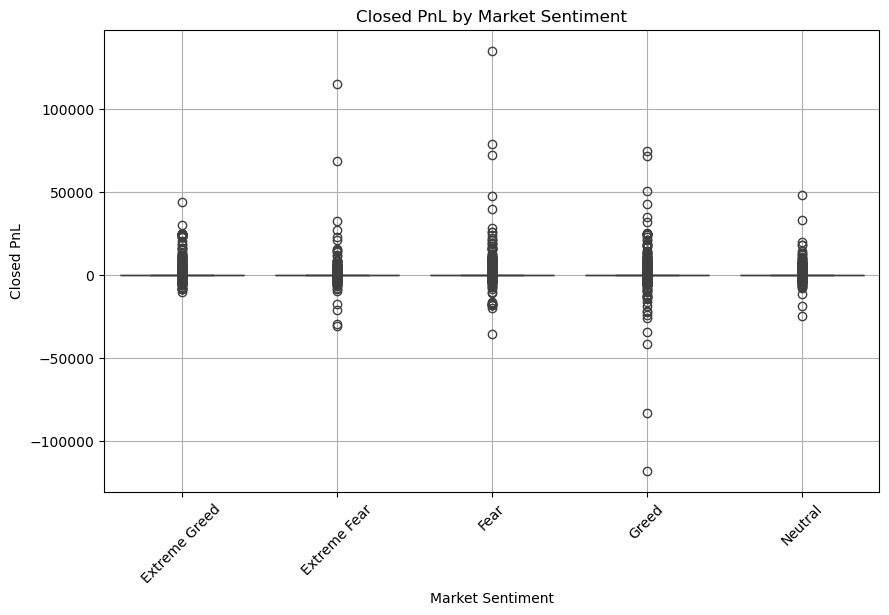

In [124]:
#boxplot of pnl by sentiment
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='Closed PnL', data=merged_df)
plt.title('Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.xticks(rotation=45)
plt.grid()

#create outputs directory if it does not exist
if not os.path.exists('outputs'):
    os.makedirs('outputs')

#save the chart
plt.savefig('outputs/closed_pnl_by_sentiment.png')
plt.show()

In [125]:
#trade volume by sentiment (USD)
merged_df.groupby('classification')['Size USD'].sum().sort_values(ascending=False)

classification
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Extreme Greed    1.244652e+08
Extreme Fear     1.144843e+08
Name: Size USD, dtype: float64

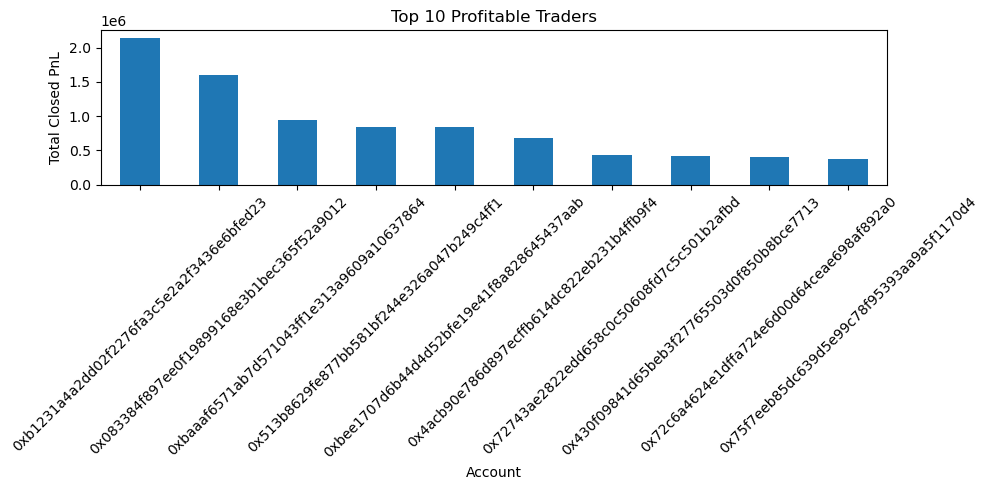

In [126]:

#top performing traders
top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
top_traders.plot(kind='bar', figsize=(10,5), title='Top 10 Profitable Traders')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/top_10_traders.png')
plt.show()


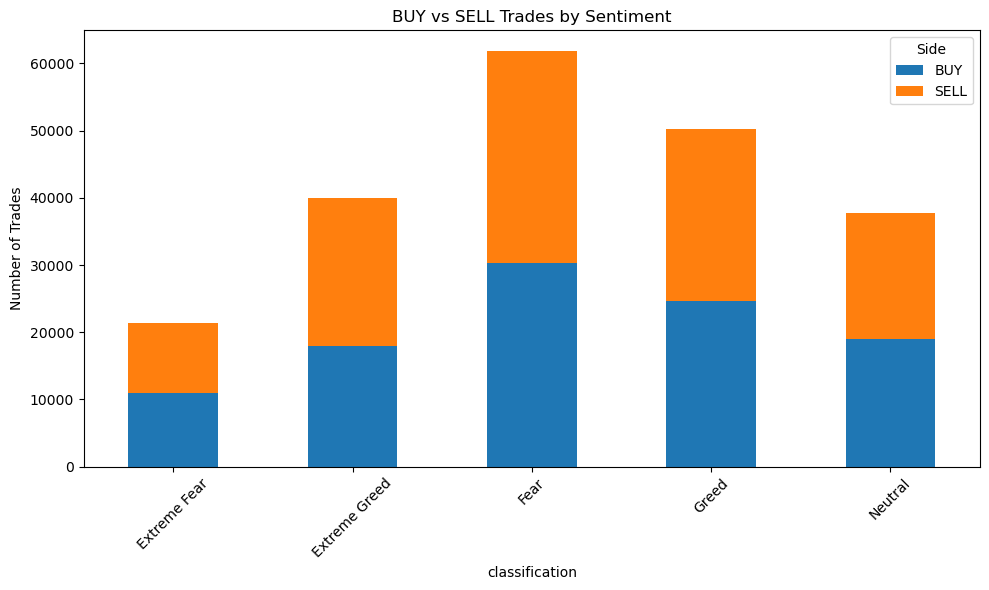

In [127]:

buy_sell = merged_df.groupby(['classification', 'Side']).size().unstack().fillna(0)

buy_sell.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("BUY vs SELL Trades by Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/buy_sell_by_sentiment.png')
plt.show()


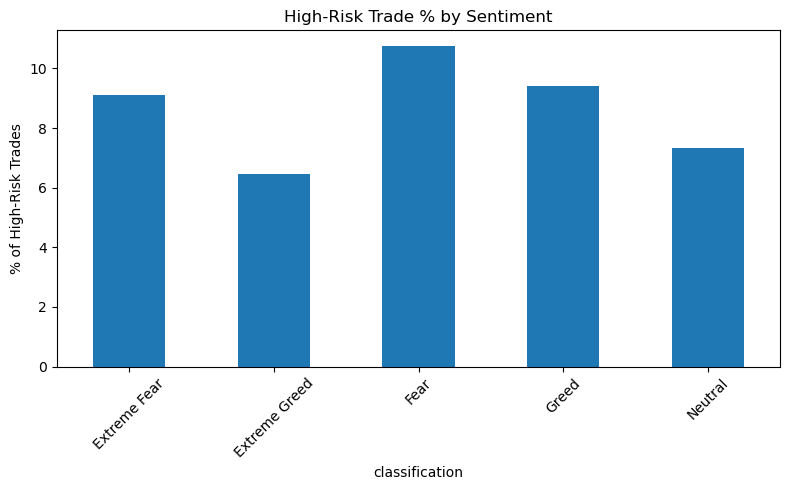

In [128]:

#Let's assume Size USD >10,000 is high-risk
merged_df['High Risk'] = merged_df['Size USD'] > 10000

risk_summary = merged_df.groupby('classification')['High Risk'].mean() * 100
risk_summary.plot(kind='bar', figsize=(8,5), title='High-Risk Trade % by Sentiment')
plt.ylabel('% of High-Risk Trades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/high_risk_trades.png')
plt.show()

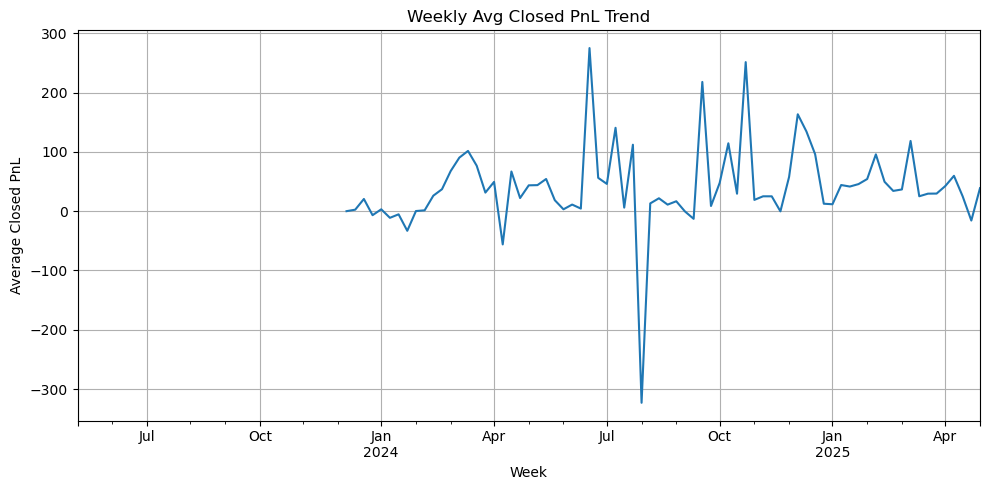

In [129]:

#trend over time (PnL trend)
merged_df['date_only'] = pd.to_datetime(merged_df['date_only'])
pnl_trend = merged_df.groupby(pd.Grouper(key='date_only', freq='W'))['Closed PnL'].mean()

pnl_trend.plot(figsize=(10,5), title='Weekly Avg Closed PnL Trend')
plt.ylabel('Average Closed PnL')
plt.xlabel('Week')
plt.grid()
plt.tight_layout()
plt.savefig('outputs/pnl_weekly_trend.png')
plt.show()

In [130]:
import os

if not os.path.exists('csv_files'):
    os.makedirs('csv_files')

merged_df.to_csv('csv_files/cleaned_trader_sentiment_data.csv', index=False)

In [132]:

!zip -r outputs.zip outputs

  adding: outputs/ (164 bytes security) (stored 0%)
  adding: outputs/buy_sell_by_sentiment.png (164 bytes security) (deflated 22%)
  adding: outputs/closed_pnl_by_sentiment.png (164 bytes security) (deflated 19%)
  adding: outputs/high_risk_trades.png (164 bytes security) (deflated 18%)
  adding: outputs/pnl_weekly_trend.png (164 bytes security) (deflated 6%)
  adding: outputs/top_10_traders.png (164 bytes security) (deflated 12%)
